In [1]:
# Install library dependencies
!pip install -qU langchain langchain-openai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.4/477.4 kB 13.3 MB/s eta 0:00:00


In [2]:
# import lanchain_openai to use LLM OpenAI API
from langchain_openai import ChatOpenAI

In [3]:
# Input API KEY
import getpass
import os

from google.colab import userdata

if not os.environ.get("OPENAI_API_KEY"):
  try:
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
  except:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

In [4]:
# define your LLM model
llm = ChatOpenAI(
    model="gpt-4o-mini"
    )

In [5]:
from typing import Annotated # for giving hint to LLM while define data type of variable

from typing_extensions import TypedDict #define an object of dataclass contains dict data type.

from langgraph.graph import StateGraph, START, END #for create agent workflow
from langgraph.graph.message import add_messages #add message operator (usually used for chat history in state)

# create state for the agent
# state is a environment that make Agent able to hold any information from any process in workflow
class State(TypedDict): # define state class
    messages: Annotated[list, add_messages] # define message object as a "list" and have add message operator
    history: list # define history object as a "list"

def chatbot(state: State): # define a function that contains all logic for chatbot node
    question = state["messages"]
    history = state["history"]
    prompt = f'''You are helpful assistant. Your task in answer the question from user and look at given chat history if needed.
question: {question}
chat history: {history}'''
    response = llm.invoke(prompt)
    return {"messages": [response]}

#build the graph for agent workflow
graph_builder = StateGraph(State) #initial the graph
graph_builder.add_node("chatbot", chatbot) #define chatbot node
graph_builder.add_edge(START, "chatbot") #connecting start node to chatbot node
graph_builder.add_edge("chatbot", END) #connectiong chatbot node to end node
graph = graph_builder.compile() #compile the graph

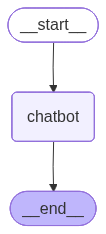

In [6]:
# show the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
# invoke our graph
graph.invoke(
    {
        "messages": [{"role": "user", "content": "halo"}],
        "history": []
    }
)

{'messages': [HumanMessage(content='halo', additional_kwargs={}, response_metadata={}, id='0579fe98-5cdf-409c-b2de-e598e329230a'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 70, 'total_tokens': 79, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_644f11dd4d', 'id': 'chatcmpl-CpWIG4MF6s4S57mrGDpETh7D6AtHH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b4557-2dce-7002-9829-e95c94ef7473-0', usage_metadata={'input_tokens': 70, 'output_tokens': 9, 'total_tokens': 79, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})],
 '

In [8]:
history = []
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        prompt = {
            "messages": [{"role": "user", "content": user_input}],
            "history": history
        }
        answer = graph.invoke(prompt)["messages"][-1].content
        print(answer)
        history.append(f"User: {user_input}")
        history.append(f"AI: {answer}")
        # print(prompt)
    except:
        # fallback if input() is not available
        user_input = "Bad Input"
        print("User: " + user_input)
        break

User: halo
Halo! How can I assist you today?
User: what benefit of implementation LLM in business?
Implementing Large Language Models (LLMs) in business can offer several benefits, including:

1. **Enhanced Customer Support**: LLMs can automate and improve customer service interactions through chatbots, providing quick responses to inquiries and resolving issues efficiently.

2. **Content Generation**: Businesses can use LLMs to create high-quality content such as marketing materials, product descriptions, and social media posts, saving time and resources.

3. **Data Analysis and Insights**: LLMs can analyze large volumes of text data, helping businesses derive insights from customer feedback, reviews, and market trends.

4. **Personalization**: By understanding customer preferences and behaviors, LLMs can help tailor marketing strategies and product recommendations to individual users.

5. **Cost Efficiency**: Automating routine tasks and improving productivity through LLM application